## Matrix plot of eML markers of Foltz*, Tran* et al., 2024 in their reference data

In [ ]:
#https://www.science.org/doi/full/10.1126/sciimmunol.adk4893

In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
from matplotlib import rcParams
import numpy as np
import seaborn as sns

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 600

In [3]:
adata=sc.read_h5ad("/Volumes/jennifer.a.foltz/Active/science_immuno_ref/fig4_reference_adata_train_posttotalvi.h5ad")

In [4]:
print(adata.X[:5, :5])

print(adata.X.dtype)

[[0.        0.        0.        0.        1.1431879]
 [0.        0.        0.        0.        0.       ]
 [0.        0.        1.7100786 0.6449434 0.       ]
 [0.        0.        1.2386584 0.        1.2386584]
 [0.        0.        1.5106838 0.        1.5106838]]
float32


In [9]:
print("Max value:", adata.X.max())
print("Mean value:", adata.X.mean())

Max value: 7.245857
Mean value: 0.24268468


In [10]:
adata

AnnData object with n_obs × n_vars = 14779 × 4000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'species', 'nCount_ADT', 'nFeature_ADT', 'nCount_HTO', 'nFeature_HTO', 'percent.mt', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'HTO_classification_species', 'Cell_Types', 'S.Score', 'G2M.Score', 'Phase', 'RNA_snn_res.0.2', 'seurat_clusters', 'unfilt_clusters', 'RNA.weight', 'ADT_denoised_iso_quant.weight', 'wsnn_res.0.6', 'wsnn_res.0.5', 'wsnn_res.0.4', 'wsnn_res.0.2', 'wsnn_res.0.3', 'NK', 'dnr_NKtype', 'main', 'NK2', 'celltype.l2', 'batch', '_scvi_labels', '_scvi_batch', 'dataset_name'
    var: 'mouse', 'KIR2', 'KIR3', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'batch_colors', 'celltype.l2_colors', 'hvg', 'log1p'
    obsm: 'X_totalvi_scarches', 'X_umap', 'protein_expression'
    layers: 'counts'

In [14]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,species,nCount_ADT,nFeature_ADT,nCount_HTO,nFeature_HTO,percent.mt,HTO_maxID,...,wsnn_res.0.3,NK,dnr_NKtype,main,NK2,celltype.l2,batch,_scvi_labels,_scvi_batch,dataset_name
3228_CAAGAAAGTGGTCCGT-1,3228,4708,2174,human,4684,28,1806,2,3.249788,Hashtag-1,...,0,CD56dim,3228_LD,CD56dim,CD56dim,CD56dim,3228,0,2,Reference
3228_GTCACGGAGACAGAGA-1,3228,3030,1430,human,2769,28,1649,2,4.455446,Hashtag-1,...,1,CD56dim,3228_LD,CD56dim,CD56dim,CD56dim,3228,0,2,Reference
3228_TTGGCAAAGGAGTTGC-1,3228,11099,3565,human,4417,28,462,2,2.513740,Hashtag-2,...,1,ML-1,3228_ML,ML,ML1,ML1,3228,0,2,Reference
3228_ATAGACCGTCAGGACA-1,3228,4093,1869,human,2720,28,1002,2,2.394332,Hashtag-2,...,1,ML-1,3228_ML,ML,ML1,ML1,3228,0,2,Reference
3228_GGTGTTACACGGCCAT-1,3228,2847,1407,human,2170,27,1244,2,3.161222,Hashtag-1,...,0,CD56dim,3228_LD,CD56dim,CD56dim,CD56dim,3228,0,2,Reference
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
451_TGACGGCGTTACTGAC-1,451,13961,3694,human,9797,26,2463,2,4.104291,Hashtag-2,...,0,CD56dim,451_ML,CD56dim,CD56dim,CD56dim,451,0,0,Reference
451_TGGCTGGAGCTAGCCC-1,451,12795,3560,human,7725,26,1971,2,4.009379,Hashtag-2,...,2,ML-2,451_ML,ML,ML2,ML2,451,0,0,Reference
451_AAAGCAACATTGGCGC-1,451,6026,2183,human,4188,26,548,2,4.596747,Hashtag-1,...,1,CD56bright,451_LD,CD56bright,CD56bright,CD56bright,451,0,0,Reference
451_GGGAGATTCATCACCC-1,451,6260,2423,human,7771,26,2429,2,4.568690,Hashtag-1,...,0,CD56dim,451_LD,CD56dim,CD56dim,CD56dim,451,0,0,Reference


In [15]:
adata.obs["NK2"].value_counts()

NK2
CD56dim       8038
ML1           2519
ML2           2247
CD56bright    1975
Name: count, dtype: int64

In [16]:
adata.obs['group'] = adata.obs['NK2'].replace({ 'ML1': 'eML', 'ML2':'eML'})

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_19579/231495901.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['group'] = adata.obs['NK2'].replace({ 'ML1': 'eML', 'ML2':'eML'})


In [17]:
adata.obs["group"].value_counts()

group
CD56dim       8038
eML           4766
CD56bright    1975
Name: count, dtype: int64

In [18]:
sc.pp.scale(adata, zero_center=True, max_value=None)

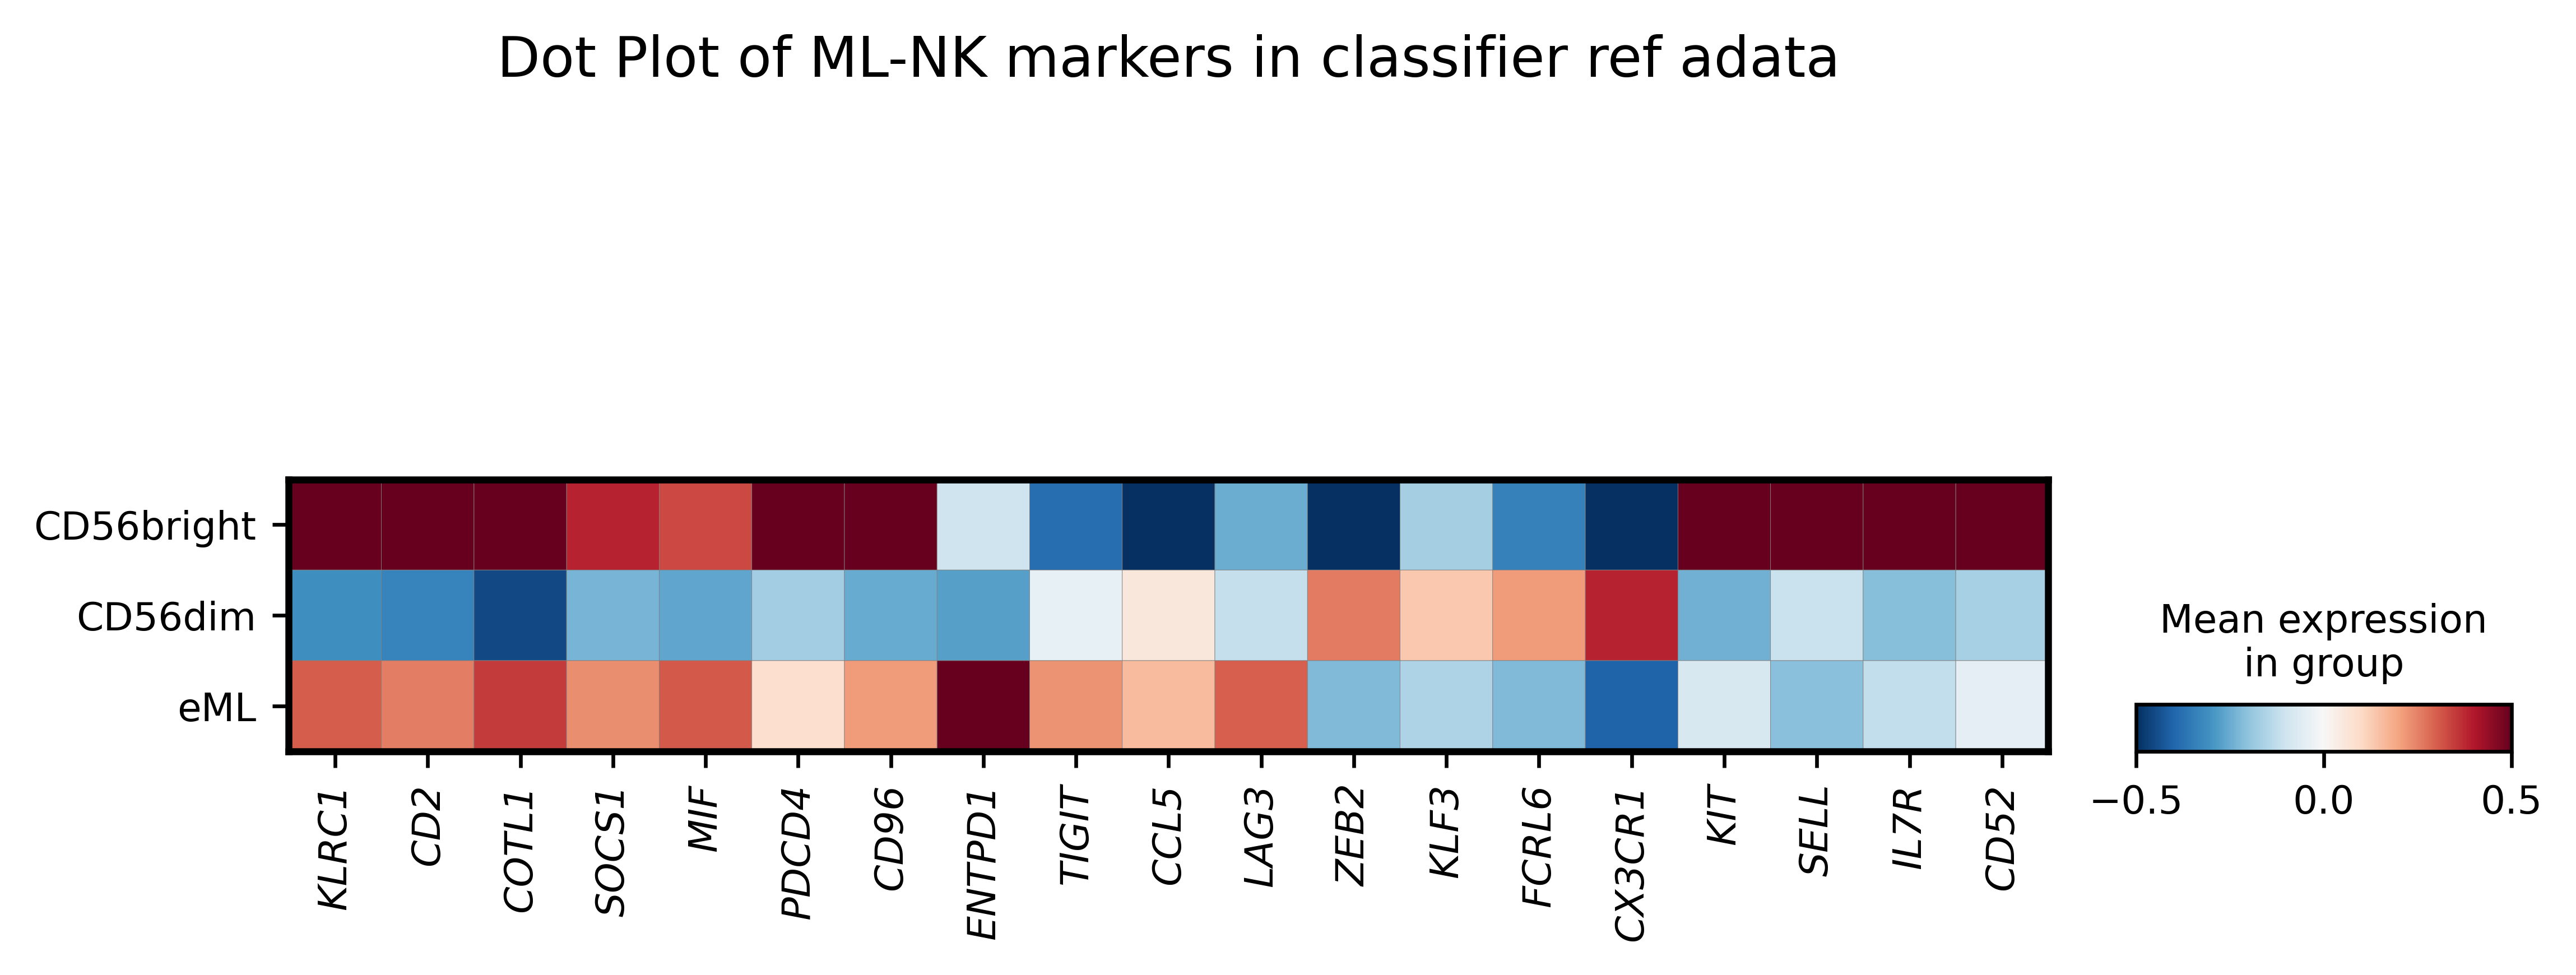

In [20]:
genes = [ "KLRC1", "CD2", "COTL1", "SOCS1", "MIF", "PDCD4", "CD96", "ENTPD1", "TIGIT", "CCL5", "LAG3", 
         #"LBH",
           "ZEB2",  "KLF3", "FCRL6", "CX3CR1",   "KIT", "SELL", "IL7R", "CD52"]

# Plot the matrixplot and get the figure object
mp = sc.pl.matrixplot(
    adata,
    var_names=genes,
    groupby='group',
    use_raw=False, 
    cmap='RdBu_r',
    vmin=-0.5, vmax=0.5, 
    swap_axes=False,
    return_fig=True,
    show=False,
    title='Dot Plot of ML-NK markers in classifier ref adata'
)

# Italicize gene names
ax = mp.get_axes()  # Main heatmap axes
for label in ax['mainplot_ax'].get_xticklabels():
    label.set_fontstyle('italic')

plt.show()
